# Task 2: Time Series Forecasting

## Guide Me in Finance (GMF) Investments

This notebook develops forecasting models for TSLA, BND, and SPY using historical market data prepared in Task 1.

Objectives:
- Prepare time series for forecasting
- Split data into training and testing sets
- Develop ARIMA forecasting models
- Evaluate forecasting accuracy
- Compare model performance

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from math import sqrt

import yfinance as yf

In [2]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    data[ticker] = df

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
closing_prices = {}

for ticker in tickers:
    closing_prices[ticker] = data[ticker]["Close"]

for ticker in tickers:
    print(f"{ticker}: {closing_prices[ticker].shape}")

TSLA: (2888,)
BND: (2888,)
SPY: (2888,)


In [4]:
train = {}
test = {}

for ticker in tickers:
    split_index = int(len(closing_prices[ticker]) * 0.8)

    train[ticker] = closing_prices[ticker][:split_index]
    test[ticker] = closing_prices[ticker][split_index:]

    print(
        f"{ticker}: "
        f"Train={len(train[ticker])}, "
        f"Test={len(test[ticker])}"
    )

TSLA: Train=2310, Test=578
BND: Train=2310, Test=578
SPY: Train=2310, Test=578


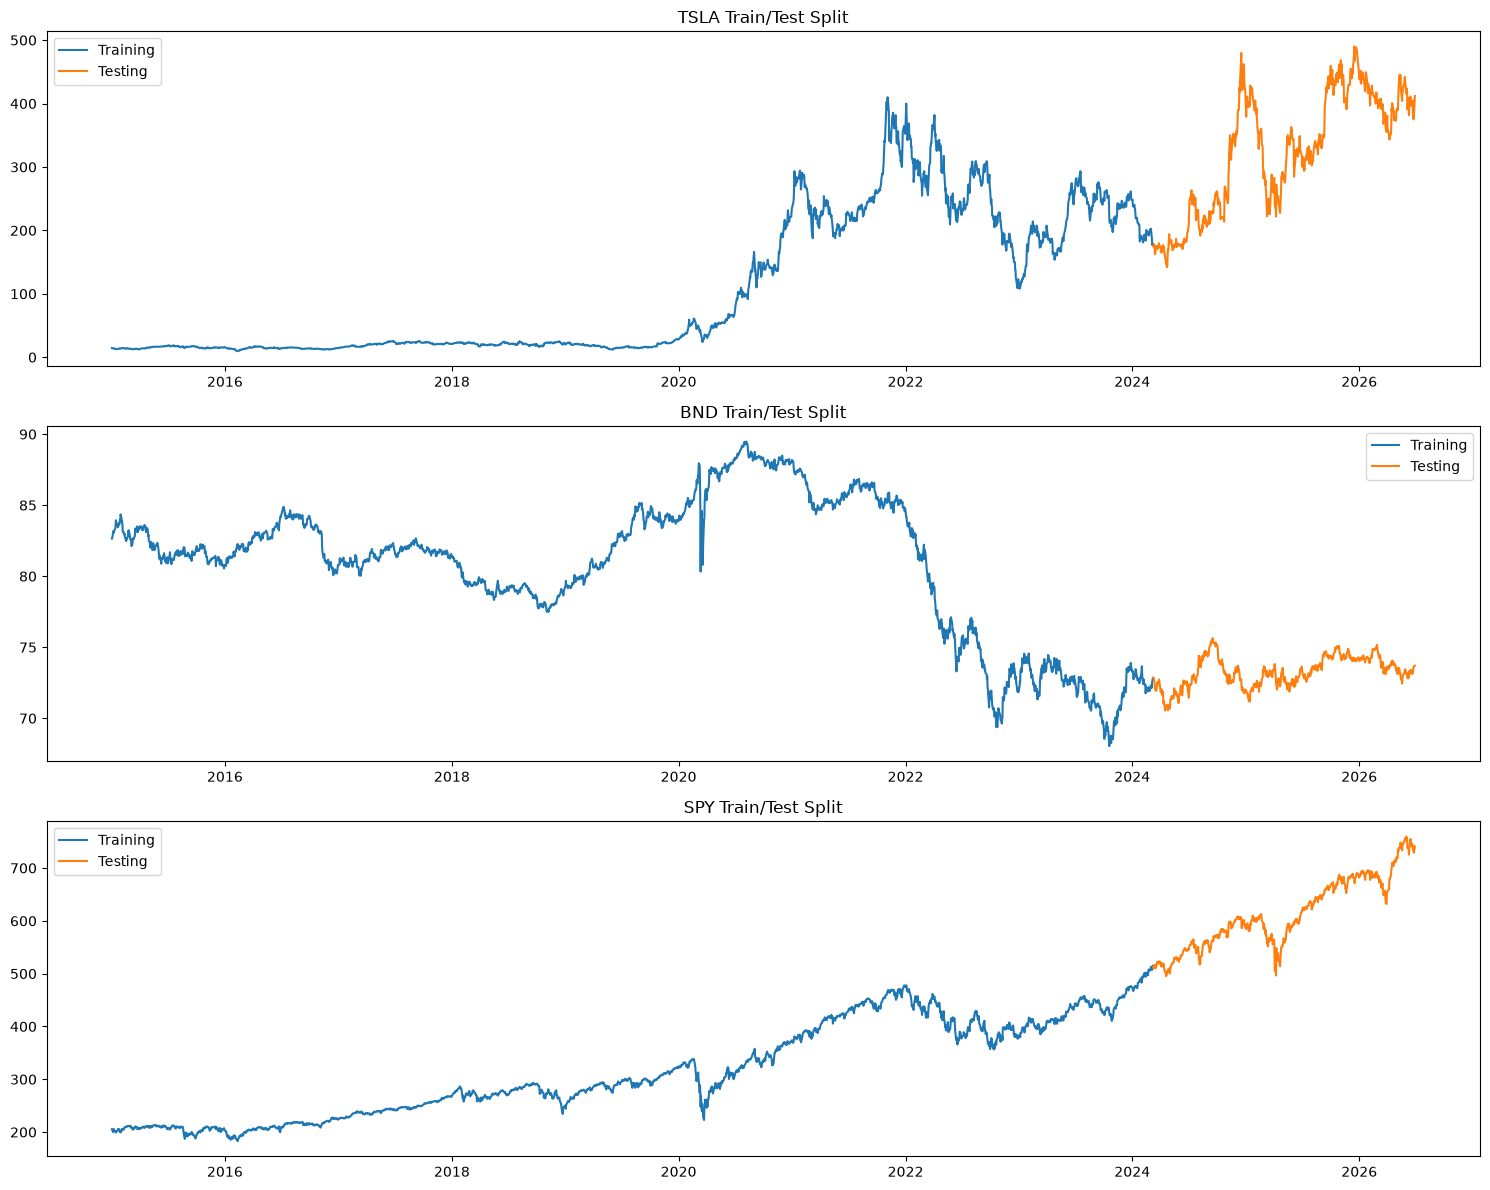

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for ax, ticker in zip(axes, tickers):
    ax.plot(train[ticker], label="Training")
    ax.plot(test[ticker], label="Testing")

    ax.set_title(f"{ticker} Train/Test Split")
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return mae, rmse, mape

In [7]:
arima_results = []
arima_predictions = {}

# Simple baseline ARIMA order.
# d=1 is used because stock prices are usually non-stationary.
arima_order = (5, 1, 0)

for ticker in tickers:
    print(f"Training ARIMA model for {ticker}...")

    model = ARIMA(train[ticker], order=arima_order)
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(test[ticker]))
    forecast.index = test[ticker].index

    arima_predictions[ticker] = forecast

    mae, rmse, mape = evaluate_forecast(test[ticker], forecast)

    arima_results.append({
        "Ticker": ticker,
        "Model": "ARIMA",
        "Order": arima_order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

arima_results_df = pd.DataFrame(arima_results)
arima_results_df

Training ARIMA model for TSLA...


c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\gebre\OneDrive\D

Training ARIMA model for BND...


c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\gebre\OneDrive\Documents\Program

Training ARIMA model for SPY...


c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Ticker,Model,Order,MAE,RMSE,MAPE
0,TSLA,ARIMA,"(5, 1, 0)",148.093176,174.369101,40.218576
1,BND,ARIMA,"(5, 1, 0)",0.948863,1.157547,1.288833
2,SPY,ARIMA,"(5, 1, 0)",99.350263,119.081579,15.233973


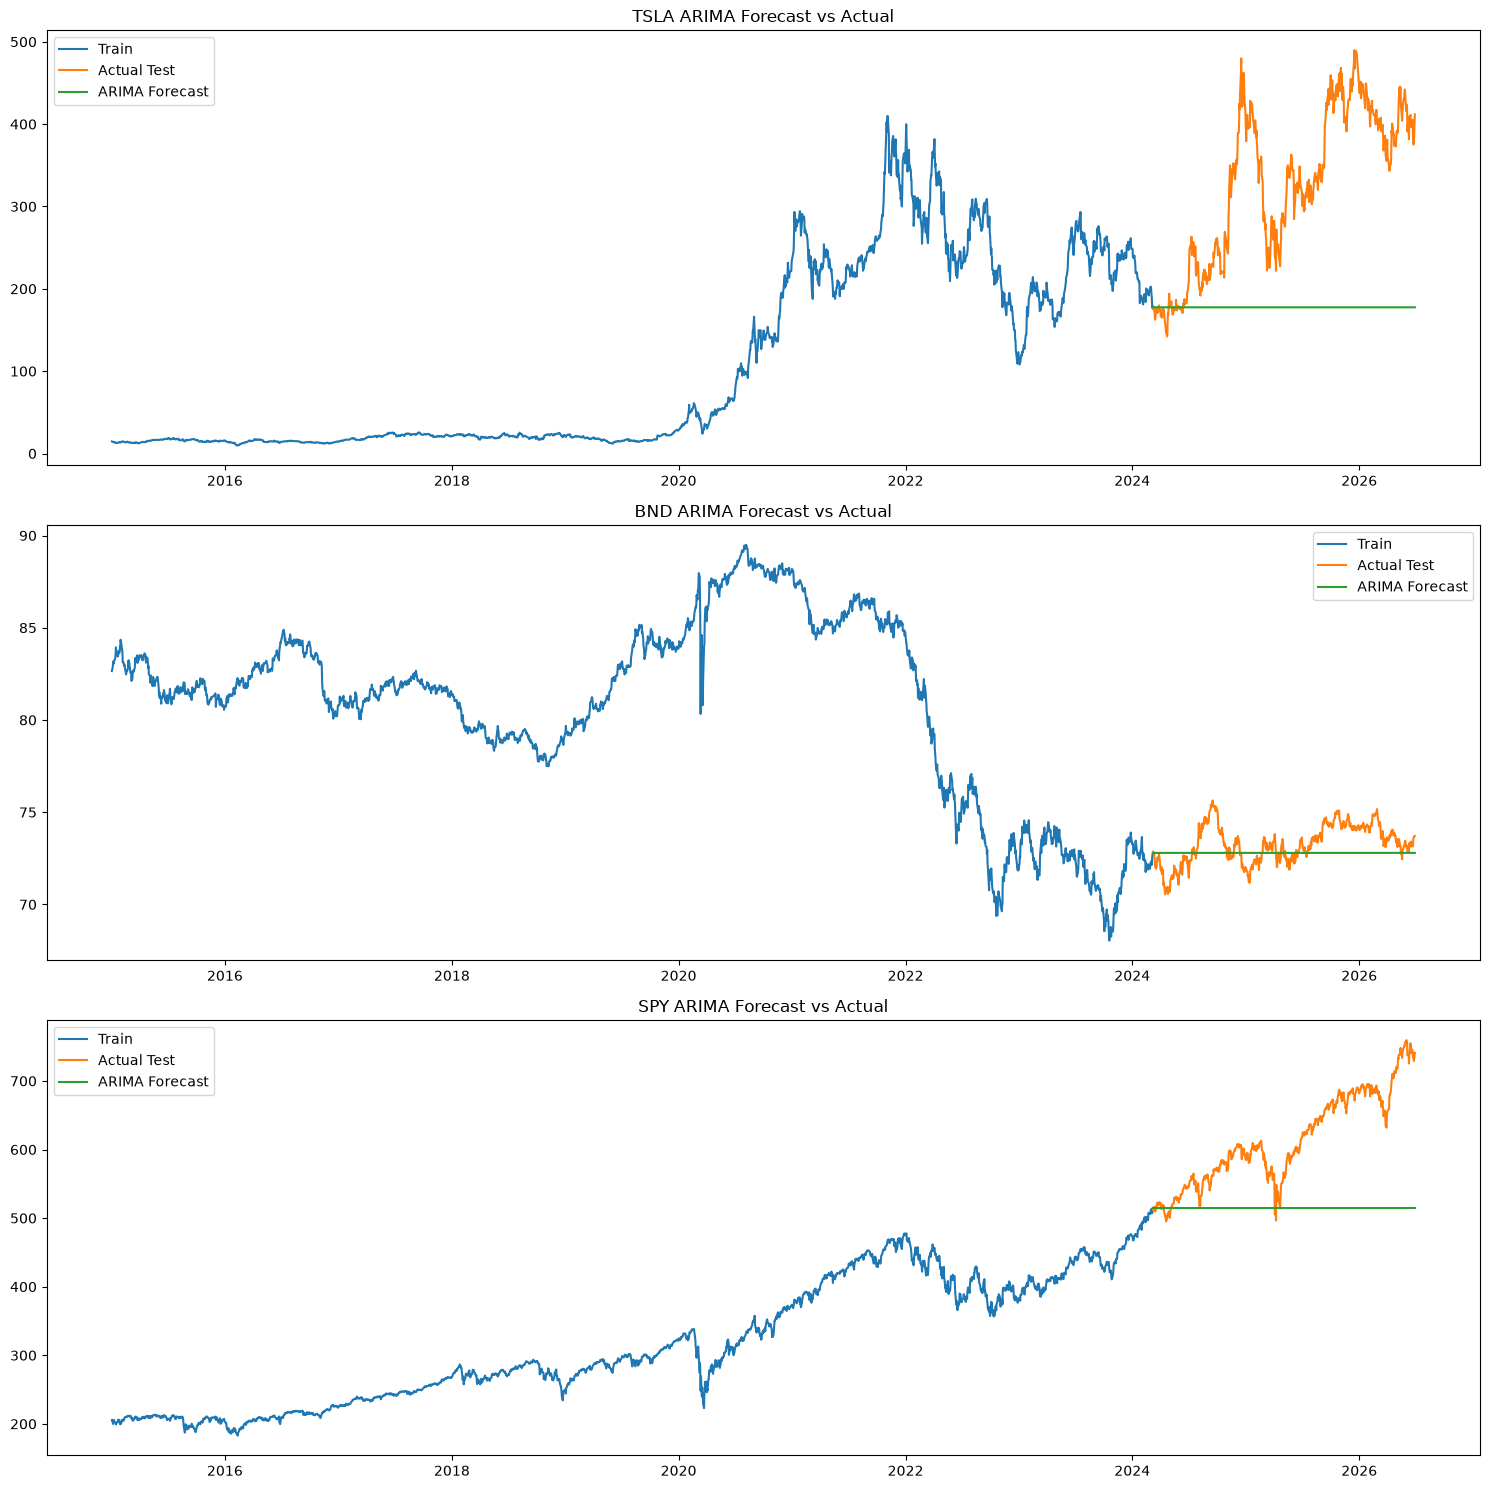

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

for ax, ticker in zip(axes, tickers):
    ax.plot(train[ticker], label="Train")
    ax.plot(test[ticker], label="Actual Test")
    ax.plot(arima_predictions[ticker], label="ARIMA Forecast")

    ax.set_title(f"{ticker} ARIMA Forecast vs Actual")
    ax.legend()

plt.tight_layout()
plt.show()

## ARIMA Model Interpretation

ARIMA was used as a classical time series forecasting baseline. The model uses past values and differencing to forecast future prices.

The order `(5, 1, 0)` was selected as a simple baseline:
- `p=5`: uses five lagged observations
- `d=1`: applies first differencing to handle non-stationarity
- `q=0`: no moving average error term

ARIMA is useful because it is interpretable and relatively fast to train. However, stock prices are highly noisy and influenced by many external factors, so ARIMA may struggle to capture sudden price movements, volatility shocks, and nonlinear patterns.

In [9]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [10]:
def create_sequences(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [11]:
lstm_results = []
lstm_predictions = {}

window_size = 60

for ticker in tickers:
    print(f"Training LSTM model for {ticker}...")

    scaler = MinMaxScaler()

    train_values = train[ticker].values.reshape(-1, 1)
    test_values = test[ticker].values.reshape(-1, 1)

    scaled_train = scaler.fit_transform(train_values)
    scaled_test = scaler.transform(test_values)

    X_train, y_train = create_sequences(scaled_train, window_size)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    model = Sequential()
    model.add(LSTM(50, return_sequences=False, input_shape=(window_size, 1)))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mean_squared_error")

    model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    combined = np.concatenate([scaled_train[-window_size:], scaled_test])
    X_test, y_test = create_sequences(combined, window_size)

    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    predictions_scaled = model.predict(X_test, verbose=0)
    predictions = scaler.inverse_transform(predictions_scaled).flatten()

    prediction_series = pd.Series(predictions, index=test[ticker].index)
    lstm_predictions[ticker] = prediction_series

    mae, rmse, mape = evaluate_forecast(test[ticker], prediction_series)

    lstm_results.append({
        "Ticker": ticker,
        "Model": "LSTM",
        "Architecture": "LSTM(50) + Dense(1)",
        "Window Size": window_size,
        "Epochs": 10,
        "Batch Size": 32,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

lstm_results_df = pd.DataFrame(lstm_results)
lstm_results_df

Training LSTM model for TSLA...
Training LSTM model for BND...
Training LSTM model for SPY...


,Ticker,Model,Architecture,Window Size,Epochs,Batch Size,MAE,RMSE,MAPE
0,TSLA,LSTM,LSTM(50) + Dense(1),60,10,32,16.374260,21.412741,4.920435
1,BND,LSTM,LSTM(50) + Dense(1),60,10,32,0.298399,0.374137,0.407628
2,SPY,LSTM,LSTM(50) + Dense(1),60,10,32,24.622797,28.845637,3.841926


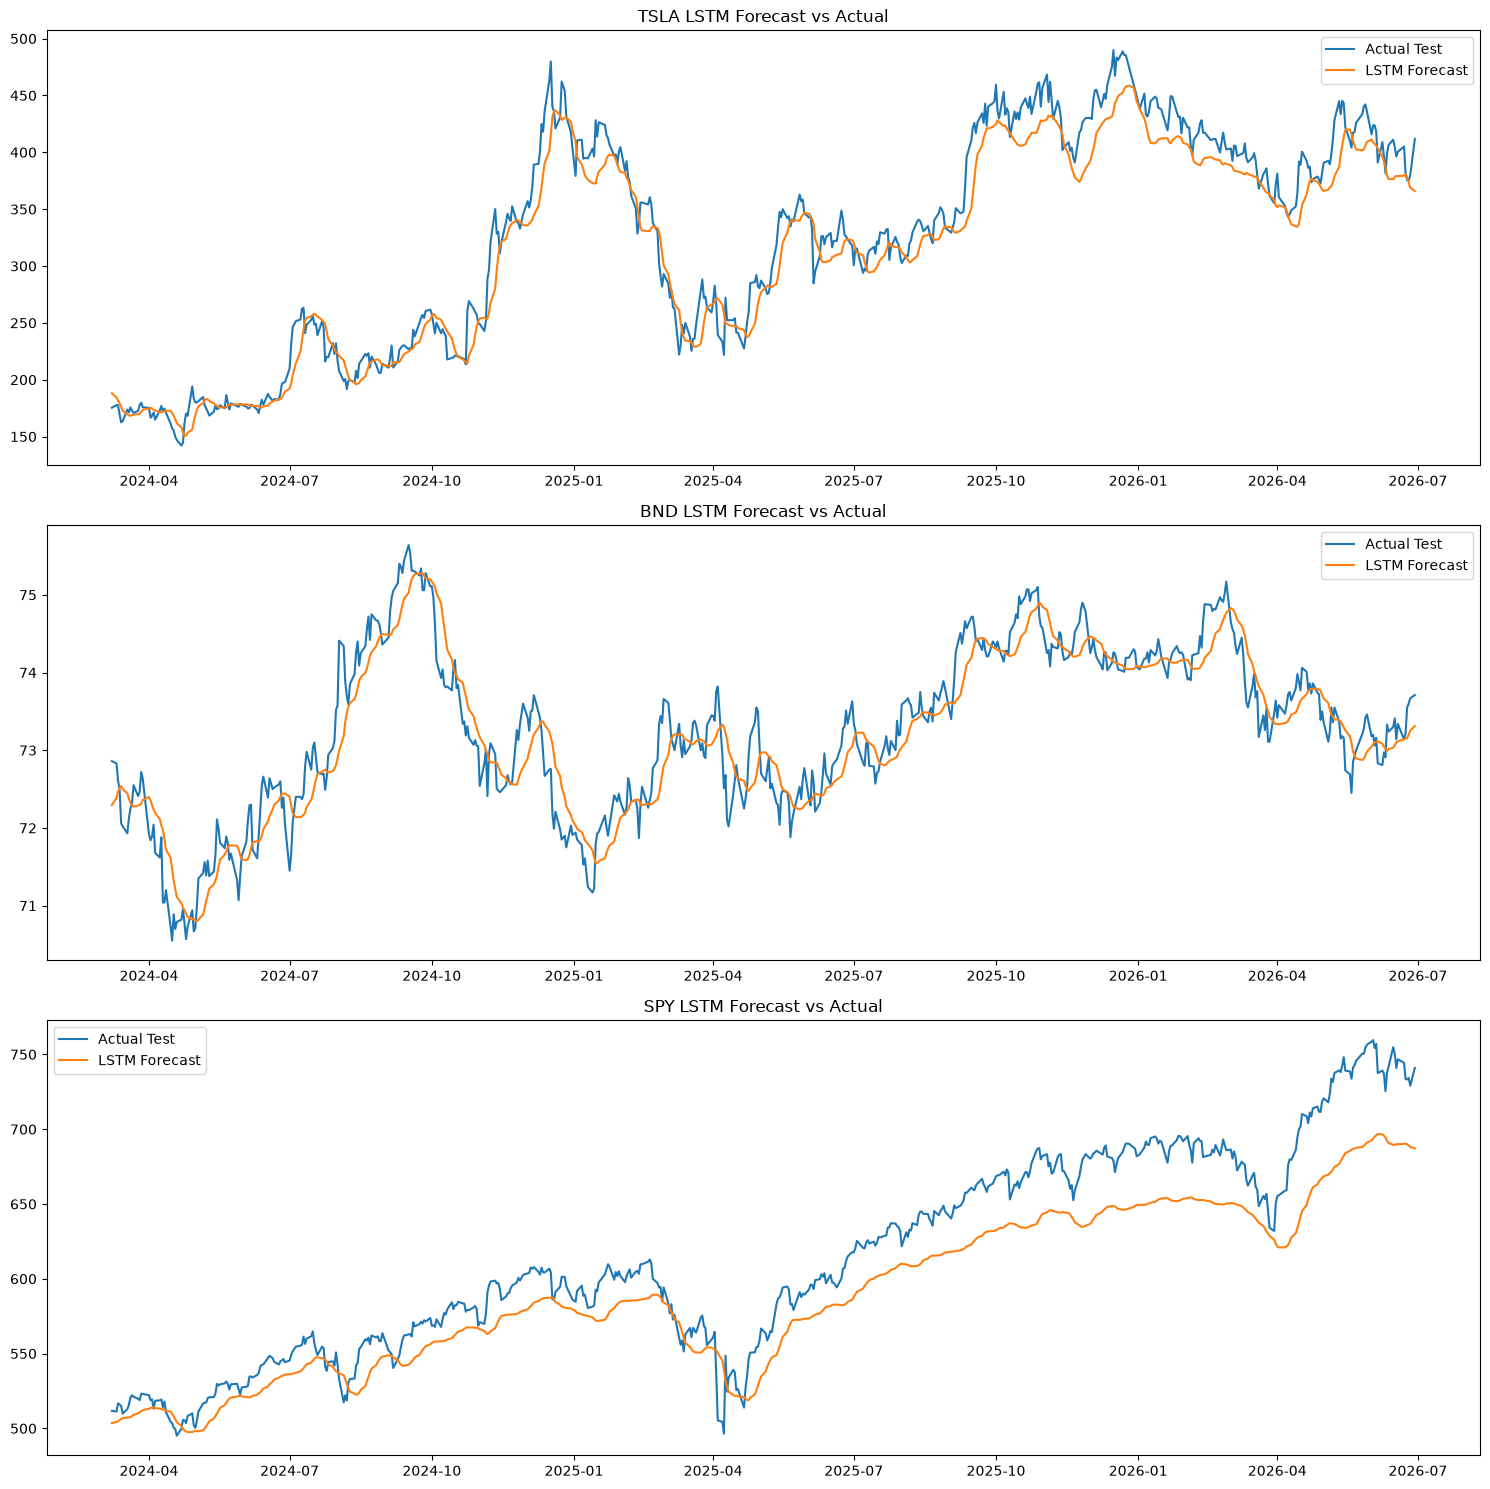

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

for ax, ticker in zip(axes, tickers):
    ax.plot(test[ticker], label="Actual Test")
    ax.plot(lstm_predictions[ticker], label="LSTM Forecast")

    ax.set_title(f"{ticker} LSTM Forecast vs Actual")
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
model_comparison = pd.concat(
    [
        arima_results_df[["Ticker", "Model", "MAE", "RMSE", "MAPE"]],
        lstm_results_df[["Ticker", "Model", "MAE", "RMSE", "MAPE"]]
    ],
    ignore_index=True
)

model_comparison

,Ticker,Model,MAE,RMSE,MAPE
0,TSLA,ARIMA,148.093176,174.369101,40.218576
1,BND,ARIMA,0.948863,1.157547,1.288833
2,SPY,ARIMA,99.350263,119.081579,15.233973
3,TSLA,LSTM,16.374260,21.412741,4.920435
4,BND,LSTM,0.298399,0.374137,0.407628
5,SPY,LSTM,24.622797,28.845637,3.841926


## Model Comparison Interpretation

ARIMA provides a strong interpretable baseline because it uses past price values and differencing to model trend behavior. It is faster to train and easier to explain to stakeholders.

LSTM is more flexible and can learn nonlinear temporal relationships from sequential data. However, it requires more preprocessing, scaling, and computational resources.

The best model is selected based on lower MAE, RMSE, and MAPE values. In financial time series forecasting, no model should be interpreted as a guarantee of future market behavior. Forecasts are best used as decision-support inputs alongside risk metrics, portfolio diversification, and market context.